In [254]:
import seaborn as sns
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

Path("diagrams").mkdir(exist_ok=True)

In [255]:
result_path = Path("../thesis_results/downstream_task")
methods_list = ["fw-mrs-temperature",  "fw-mrs-temperature-svm"]
# bias_types = ["less_negative_class", "less_positive_class", "mean_difference"]
bias_types = ["less_positive_class"]
less_bias_strengths = ["0.1"]
mean_bias_strengthts = ["0.8"]
datasets = ["folktables_employment", "folktables_income", "hr_analytics", "breast_cancer", "loan_prediction"]

## Plot per temperature

In [256]:
dict_list = []
auroc_dict_list = []

for dataset in datasets:
    for bias_type in bias_types:
        for method in methods_list:
            if bias_type == "mean_difference":
                bias_strengths = mean_bias_strengthts
            else : 
                bias_strengths = less_bias_strengths
            for bias_strength in bias_strengths:
                dropped_samples_file_name = result_path / dataset / bias_type /  bias_strength/ method / "validation/dropped_samples_individual_val_dict.json"
                auroc_file_name = result_path / dataset / bias_type /  bias_strength/ method / "validation"/ "auroc_individual_val_dict.json"
                dropped_samples_file = pd.read_json(str(dropped_samples_file_name), orient="records", typ="series", convert_axes=False)
                auroc_file = pd.read_json(str(auroc_file_name), orient="records", typ="series", convert_axes=False)
                dict_list.append(
                    {
                        "Dropped Samples": dropped_samples_file,
                        "Data Set": dataset,
                        "Method": method,
                        "bias_type": bias_type,
                        "bias_strength": bias_strength,
                    }
                                )
                auroc_dict_list.append(
                    {
                        "AUROC": auroc_file
                }
                )

result_df = pd.DataFrame(data=dict_list)
auroc_result_df = pd.DataFrame(data=auroc_dict_list)
result_df = pd.concat([result_df.drop(['Dropped Samples'], axis=1),result_df["Dropped Samples"].apply(pd.Series)], axis=1)
temperatures = ["0.1", "0.05", "0.01", "0.005"]
result_df = result_df.explode(temperatures)
result_df = result_df.melt(var_name="Temperature", value_name="Dropped Samples", value_vars=temperatures, 
                        id_vars=result_df.drop(columns=temperatures).columns)
auroc_result_df = pd.concat([auroc_result_df.drop(['AUROC'], axis=1),auroc_result_df["AUROC"].apply(pd.Series)], axis=1)
auroc_result_df = auroc_result_df.explode(temperatures)
auroc_result_df = auroc_result_df.melt(var_name="Temperature", value_name="AUROC", value_vars=temperatures)

result_df = pd.concat([result_df, auroc_result_df["AUROC"]], axis=1)

## Load MRS

In [257]:
mrs_dict_list = []
mrs_auroc_dict_list = []

for dataset in datasets:
    for bias_type in bias_types:
        if bias_type == "mean_difference":
            bias_strengths = mean_bias_strengthts
        else : 
            bias_strengths = less_bias_strengths
        for bias_strength in bias_strengths:
            dropped_samples_file_name = result_path / dataset / bias_type /  bias_strength/ "mrs-forest" / "validation" / "dropped_samples_individual_val_dict.json"
            auroc_file_name = result_path / dataset / bias_type /  bias_strength/ "mrs-forest" / "validation"/ "auroc_individual_val_dict.json"
            dropped_samples_file = pd.read_json(str(dropped_samples_file_name), orient="records", typ="series", convert_axes=False)
            auroc_file = pd.read_json(str(auroc_file_name), orient="records", typ="series", convert_axes=False)
            mrs_dict_list.append(
                {
                    "Dropped Samples": dropped_samples_file["0.0"]["0.01"],
                    "Data Set": dataset,
                    "Method": "MRS",
                    "bias_type": bias_type,
                    "bias_strength": bias_strength,
                }
                            )
            mrs_auroc_dict_list.extend(auroc_file["0.0"]["0.01"])
mrs_result_df = pd.DataFrame(data=mrs_dict_list)
mrs_result_df = mrs_result_df.explode("Dropped Samples")
mrs_result_df["Temperature"] = "MRS"
mrs_result_df["AUROC"] = mrs_auroc_dict_list

In [258]:
result_df = pd.concat([result_df, mrs_result_df], axis=0)
result_df

,Data Set,Method,bias_type,bias_strength,Temperature,Dropped Samples,AUROC
0,folktables_employment,fw-mrs-temperature,less_positive_class,0.1,0.1,305,0.835317
1,folktables_employment,fw-mrs-temperature,less_positive_class,0.1,0.1,255,0.831602
2,folktables_employment,fw-mrs-temperature,less_positive_class,0.1,0.1,295,0.833242
3,folktables_employment,fw-mrs-temperature,less_positive_class,0.1,0.1,250,0.832768
4,folktables_employment,fw-mrs-temperature,less_positive_class,0.1,0.1,360,0.843356
...,...,...,...,...,...,...,...
4,loan_prediction,MRS,less_positive_class,0.1,MRS,5,0.461833
4,loan_prediction,MRS,less_positive_class,0.1,MRS,14,0.587358
4,loan_prediction,MRS,less_positive_class,0.1,MRS,13,0.705238
4,loan_prediction,MRS,less_positive_class,0.1,MRS,2,0.714646


In [259]:
result_df["Dropped Samples"] = result_df["Dropped Samples"].astype(float)
result_df = result_df.replace({"fw-mrs-temperature": "FW-MRS-RF", "mrs-forest": "MRS", "fw-mrs-temperature-svm": "FW-MRS-SVM"})
result_df = result_df.replace({"folktables_employment": "Employment", "folktables_income": "Income",
                              "breast_cancer": "Breast Cancer", "hr_analytics": "HR Analytic", "loan_prediction": "Loan"})
result_df.loc[result_df["Data Set"] == "Employment", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Employment", "Dropped Samples"] / 1408)
result_df.loc[result_df["Data Set"] == "Income", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Income", "Dropped Samples"] / 1448)
result_df.loc[result_df["Data Set"] == "HR Analytic", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "HR Analytic", "Dropped Samples"] / 3048)
result_df.loc[result_df["Data Set"] == "Breast Cancer", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Breast Cancer", "Dropped Samples"] / 113)
result_df.loc[result_df["Data Set"] == "Loan", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Loan", "Dropped Samples"] / 72)

In [260]:
result_df

,Data Set,Method,bias_type,bias_strength,Temperature,Dropped Samples,AUROC
0,Employment,FW-MRS-RF,less_positive_class,0.1,0.1,0.216619,0.835317
1,Employment,FW-MRS-RF,less_positive_class,0.1,0.1,0.181108,0.831602
2,Employment,FW-MRS-RF,less_positive_class,0.1,0.1,0.209517,0.833242
3,Employment,FW-MRS-RF,less_positive_class,0.1,0.1,0.177557,0.832768
4,Employment,FW-MRS-RF,less_positive_class,0.1,0.1,0.255682,0.843356
...,...,...,...,...,...,...,...
4,Loan,MRS,less_positive_class,0.1,MRS,0.069444,0.461833
4,Loan,MRS,less_positive_class,0.1,MRS,0.194444,0.587358
4,Loan,MRS,less_positive_class,0.1,MRS,0.180556,0.705238
4,Loan,MRS,less_positive_class,0.1,MRS,0.027778,0.714646


## With AUROC

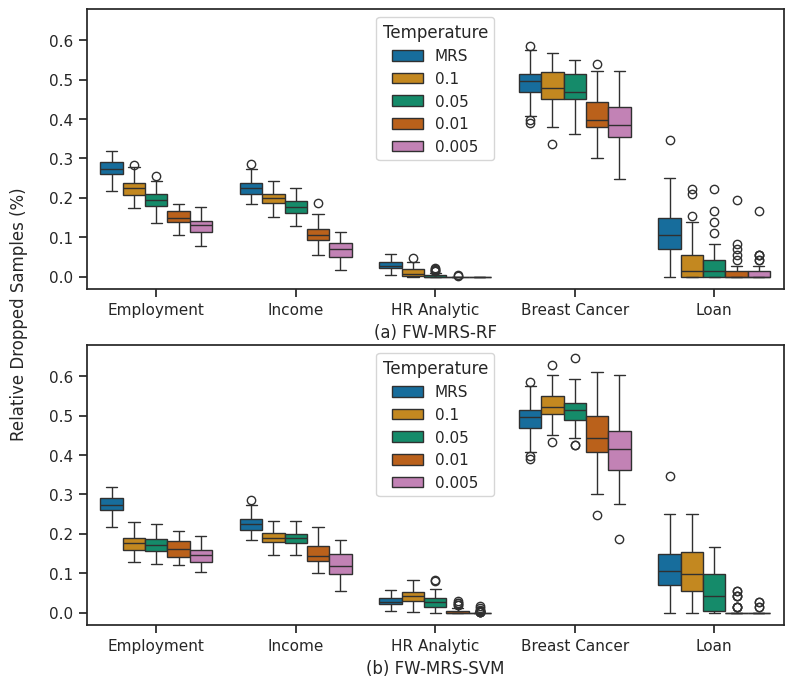

In [261]:
fig, axes = plt.subplots(2, 1, sharey=True, sharex=False, figsize=(9, 8))
ylabel="Relative Dropped Samples (%)"
sns.set_theme(style="ticks", palette="colorblind")
sns.boxplot(data=result_df[result_df["Method"].isin(["MRS", "FW-MRS-RF"])], y="Dropped Samples", x="Data Set", 
            hue="Temperature", legend=True, hue_order=["MRS", "0.1", "0.05", "0.01", "0.005"],
              ax=axes[0]).set(xlabel="(a) FW-MRS-RF",  ylabel=None)
axes[0].xaxis.get_label().set_visible(True) 
sns.boxplot(data=result_df[result_df["Method"].isin(["MRS", "FW-MRS-SVM"])], y="Dropped Samples", x="Data Set", 
           hue="Temperature", ax=axes[1], hue_order=["MRS", "0.1", "0.05", "0.01", "0.005"]).set(xlabel="(b) FW-MRS-SVM", ylabel=None)
fig.text(0.05,0.5, ylabel, ha="center", va="center", rotation=90)
plt.savefig("diagrams/dropped_samples_per_temperature_fixed.pdf")

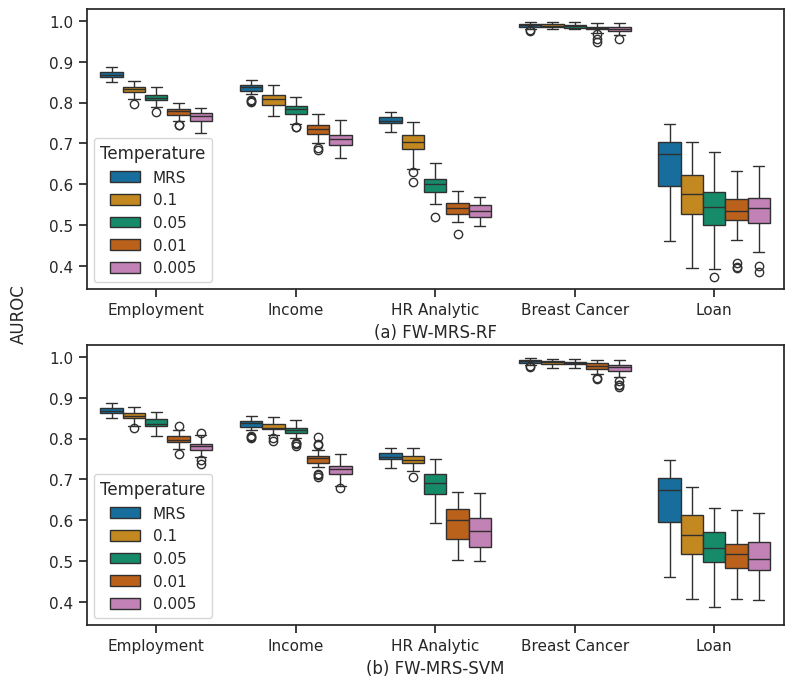

In [262]:
fig, axes = plt.subplots(2, 1, sharey=True, sharex=False, figsize=(9, 8))
ylabel="AUROC"
sns.set_theme(style="ticks", palette="colorblind")
sns.boxplot(data=result_df[result_df["Method"].isin(["MRS", "FW-MRS-RF"])], y="AUROC", x="Data Set", 
            hue="Temperature", legend=True, hue_order=["MRS", "0.1", "0.05", "0.01", "0.005"],
              ax=axes[0]).set(xlabel="(a) FW-MRS-RF",  ylabel=None)
axes[0].xaxis.get_label().set_visible(True) 
sns.boxplot(data=result_df[result_df["Method"].isin(["MRS", "FW-MRS-SVM"])], y="AUROC", x="Data Set", 
           hue="Temperature", ax=axes[1], hue_order=["MRS", "0.1", "0.05", "0.01", "0.005"]).set(xlabel="(b) FW-MRS-SVM", ylabel=None)
fig.text(0.05,0.5, ylabel, ha="center", va="center", rotation=90)
plt.savefig("diagrams/auroc_per_temperature_fixed.pdf")

## Plot per method

In [263]:
methods_list = ["fw-mrs-temperature",  "fw-mrs-temperature-svm", "mrs-forest"]
aurocs = []
auprcs = []
dict_list = []
for dataset in datasets:
    for bias_type in bias_types:
        for method in methods_list:
            if bias_type == "mean_difference":
                bias_strengths = mean_bias_strengthts
            else : 
                bias_strengths = less_bias_strengths
            for bias_strength in bias_strengths:
                dropped_samples_file = result_path / dataset / bias_type /  bias_strength/ method / "classification_results" / "dropped_samples.json"
                dropped_samples_file = pd.read_json(str(dropped_samples_file), typ="series")
                dict_list.append(
                    {
                        "Dropped Samples": dropped_samples_file,
                        "Data Set": dataset,
                        "Method": method,
                        "bias_type": bias_type,
                        "bias_strength": bias_strength,
                    }
                                )
result_df = pd.DataFrame(data=dict_list)
result_df = result_df.explode(column="Dropped Samples", ignore_index=True)
result_df = result_df.replace({"fw-mrs-temperature": "FW-MRS-RF", "mrs-forest": "MRS", "fw-mrs-temperature-svm": "FW-MRS-SVM"})
result_df = result_df.replace({"folktables_employment": "Employment", "folktables_income": "Income",
                               "breast_cancer": "Breast Cancer", "hr_analytics": "HR Analytic", "loan_prediction": "Loan"})

In [264]:
result_df["Dropped Samples"] = result_df["Dropped Samples"].astype(float)
result_df.loc[result_df["Data Set"] == "Employment", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Employment", "Dropped Samples"] / 1408)
result_df.loc[result_df["Data Set"] == "Income", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Income", "Dropped Samples"] / 1448)
result_df.loc[result_df["Data Set"] == "HR Analytic", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "HR Analytic", "Dropped Samples"] / 3048)
result_df.loc[result_df["Data Set"] == "Breast Cancer", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Breast Cancer", "Dropped Samples"] / 113)
result_df.loc[result_df["Data Set"] == "Loan", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Loan", "Dropped Samples"] / 72)

result_df

,Dropped Samples,Data Set,Method,bias_type,bias_strength
0,0.110085,Employment,FW-MRS-RF,less_positive_class,0.1
1,0.081676,Employment,FW-MRS-RF,less_positive_class,0.1
2,0.102983,Employment,FW-MRS-RF,less_positive_class,0.1
3,0.053267,Employment,FW-MRS-RF,less_positive_class,0.1
4,0.092330,Employment,FW-MRS-RF,less_positive_class,0.1
...,...,...,...,...,...
745,0.041667,Loan,MRS,less_positive_class,0.1
746,0.222222,Loan,MRS,less_positive_class,0.1
747,0.166667,Loan,MRS,less_positive_class,0.1
748,0.027778,Loan,MRS,less_positive_class,0.1


## Test Results

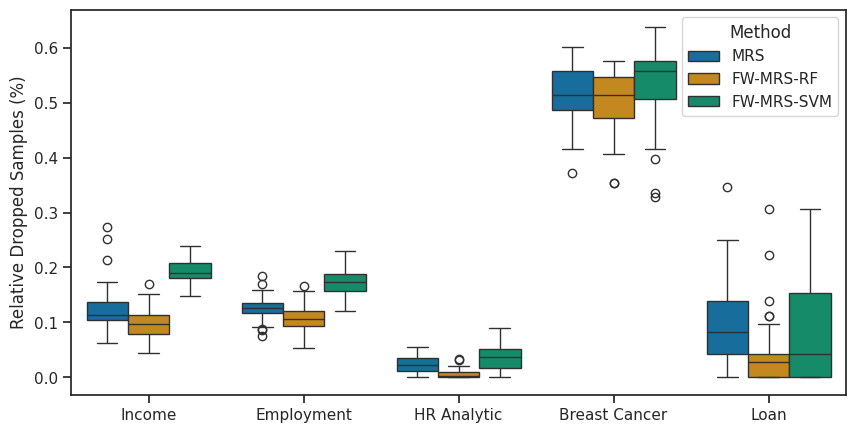

In [266]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=result_df, y="Dropped Samples", x="Data Set", hue="Method",
            order=["Income", "Employment", "HR Analytic", "Breast Cancer", "Loan"],
            hue_order=["MRS","FW-MRS-RF", "FW-MRS-SVM"]).set(xlabel=None, ylabel="Relative Dropped Samples (%)")
plt.savefig("diagrams/relative_dropped_samples_per_method_complete.pdf", bbox_inches="tight")